Program: American Roulette with Constant Bet  
Author: C.D. Wentworth  
Version: 9.1.2022.1  
Summary:  
        This program performs a Monte Carlo simulation of the
        American roulette game using a constant bet strategy based
        either color choice or specific value choice.  
History:  
    9.1.2022.1: base  

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def spin(values,colors):
#    i = rn.randint(0, 37)
    i = rng.integers(low=0 , high=38 )
    value = values[i]
    color = colors[i]
    return value, color

def make_a_play(balance, bet_amount, bet_type, bet_types,
                values, colors):
    spin_value, spin_color = spin(values, colors)
    if bet_type == 'black':
        if spin_color == 'black':
            balance = balance + bet_amount*bet_types['black']
        else:
            balance = balance - bet_amount
    if bet_type == 'red':
        if spin_color == 'red':
            balance = balance + bet_amount*bet_types['red']
        else:
            balance = balance - bet_amount
    if bet_type == 'green':
        if spin_color == 'green':
            balance = balance + bet_amount*bet_types['green']
        else:
            balance = balance - bet_amount
    else:
        if spin_value == bet_type:
            balance = balance + bet_amount*bet_types['value']
        else:
            balance = balance - bet_amount
    return balance

def game_constant_bet(balance, stop_balance, bet_amount, bet_type,
                      bet_types, values, colors):
    balance_series = [balance]
    while (balance > 0) and (balance < stop_balance):
        balance = make_a_play(balance, bet_amount, bet_type, bet_types,
                  values, colors)
        balance_series.append(balance)
    return balance_series

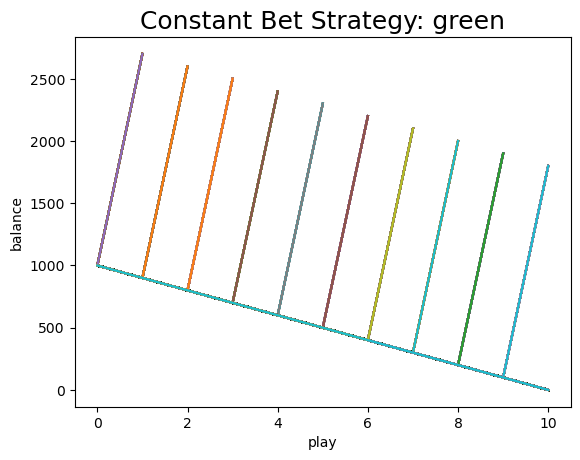

In [6]:
# Main Program

# Initialize gambler's data
balance = 1000
stop_balance = 1200
bet_amount = 100
bet_type = 'green'
#bet_type = '10'
number_of_games = 1000

# Set up the numpy random number generator
rng = np.random.default_rng(314159)

# Initialize the bet type payout
bet_types = {'black': 1, 'red': 1, 'green': 17, 'value': 35  }

# Read in the wheel data
df = pd.read_csv('wheel.txt', sep='\t', header=1,
       dtype={'index':int, 'value':'string', 'color':'string'})

# Convert pandas columns to tuples
values = tuple(df['value'].tolist())
colors = tuple(df['color'].tolist())

for g in range(number_of_games):
    balance_series = game_constant_bet(balance, stop_balance,
                                       bet_amount, bet_type,
                                       bet_types, values, colors)
    plt.plot(balance_series)
plt.xlabel('play')
plt.ylabel('balance')
title_string = 'Constant Bet Strategy: ' + str(bet_type)
plt.title(title_string, fontsize=18)
plt.savefig('roulette_constantBet_value15_1200.png', dpi=300)
plt.show()

In [4]:
values

('0',
 '28',
 '9',
 '26',
 '30',
 '11',
 '7',
 '20',
 '32',
 '17',
 '5',
 '22',
 '34',
 '15',
 '3',
 '24',
 '36',
 '13',
 '1',
 '00',
 '27',
 '10',
 '25',
 '39',
 '12',
 '8',
 '19',
 '31',
 '18',
 '6',
 '21',
 '33',
 '16',
 '4',
 '23',
 '35',
 '14',
 '2')